## Download DEM

This is an example workflow for easily obtaining a digital elevation model (DEM) topograhic data from OpenTopography.
To obtain a DEM from OpenTopography, a user needs to supply the lattitude and longitude of the bounding box of the region of interest. 
OpenTopography also needs the desired DEM format (ASCII or GeoTIFF) and the source database to pull from (see list above). 

The global datasets available are listed below. Please enter one below.
  -  SRTMGL3 (SRTM GL3 90m)
  -  SRTMGL1 (SRTM GL1 30m)
  -  SRTMGL1_E (SRTM GL1 Ellipsoidal 30m)
  -  AW3D30 (ALOS World 3D 30m)
  -  AW3D30_E (ALOS World 3D Ellipsoidal, 30m)
  -  SRTM15Plus (Global Bathymetry SRTM15+ V2.1)
  -  NASADEM (NASADEM Global DEM)
  -  COP30 (Copernicus Global DSM 30m)
  -  COP90 (Copernicus Global DSM 90m)
  -  EU_DTM (DTM 30m)

The script will save the resulting DEM with a standardize file name in the user's home directory. 

### Import needed libraries

In [3]:
import urllib.request
import utm
import sys
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import rasterio as rio
import xarray as xr

import openpyxl

In [4]:
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

### Setting input parameters

In the following cell we use the lat/lon of a target volcano's summit, obtained from the Global Volcano Project database from the volcano'es name, to set the bounding box.


In [5]:
#Choose a volcano and DEM options

volcano = victor.search_volcano('Pinatubo') # Get volcano information from the GVP database

center_lat = volcano[1][0]  # Get volcano latitude
center_lon = volcano[2][0]  # Get volcano longitude

# Set the extent of the region of interest, in meters in each direction from the summit
eastwest_extent = 11000
northsouth_extent = 8000

# Set bounding box in lat/lon
utms = utm.from_latlon(center_lat, center_lon)
[north_lat, east_lon] = utm.to_latlon(utms[0]+eastwest_extent, utms[1]+northsouth_extent, utms[2], utms[3])
[south_lat, west_lon] = utm.to_latlon(utms[0]-eastwest_extent, utms[1]-northsouth_extent, utms[2], utms[3])

# Select a DEM format: Input "ascii" for ASCII format (.asc) and "tiff" for geotiff format
outputFormat = "tiff"

# Enter the name of the output file (without extension)
name = "Pinatubu"

dataset = "SRTMGL1"

print(center_lat, center_lon) 

15.13 120.35


### Obtain DEM 
This cells obtains the DEM from OpenTopograhy using the input options. It will print out the resulting file name. 

In [7]:
dem = victor.download_dem(north_lat, south_lat, east_lon, west_lon, outputFormat, dataset)
print (dem)

DEM downloaded as DEM_15N_15S_120W_120E_SRTMGL1_13082024
DEM_15N_15S_120W_120E_SRTMGL1_13082024


### DEM Visualization 
To make sure we got what we wanted, the next cell will plot the DEM using the victor.py DEM visualization function

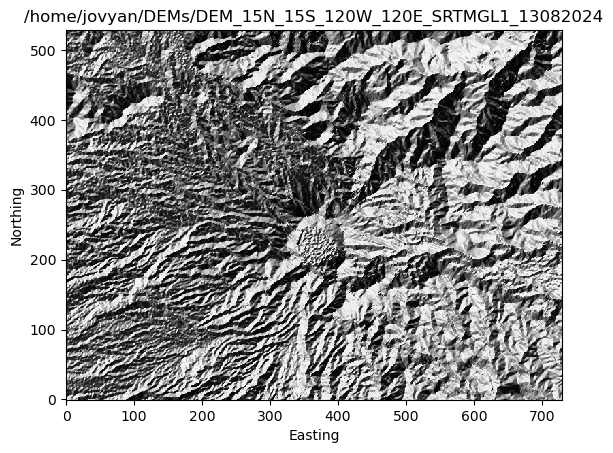

In [8]:
victor.plot_dem('/home/jovyan/'+dem)
plt.savefig(name)

In [2]:
# %load /home/jovyan/pyFLOWGO/main_flowgo.py
# Copyright 2017 PyFLOWGO development team (Magdalena Oryaelle Chevrel and Jeremie Labroquere)
#
# This file is part of the PyFLOWGO library.
#
# The PyFLOWGO library is free software: you can redistribute it and/or modify
# it under the terms of the the GNU Lesser General Public License as published by
# the Free Software Foundation; either version 3 of the License, or
# (at your option) any later version.
#
# The PyFLOWGO library is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# You should have received copies of the GNU Lesser General Public License
# along with the PyFLOWGO library.  If not, see https://www.gnu.org/licenses/.

import pyflowgo.flowgo_terrain_condition
import pyflowgo.flowgo_model_factory
import pyflowgo.flowgo_integrator
import pyflowgo.flowgo_state
import pyflowgo.flowgo_logger

import json
import argparse

if __name__ == "__main__":

    parser = argparse.ArgumentParser(description='Gives the configuration file as input.')
    parser.add_argument('configuration_file', metavar='example_input_parameters.json', type=str, nargs=1,
                        help='the configuration file to be used by PyFlowGo')

    args = parser.parse_args()
    configuration_file = args.configuration_file[0]

    # ---------------------------------- LOAD CONFIGURATION FILE AND INPUT PARAMETERS ----------------------------------
    # TODO:choose the configuration file in the edit parameters

    # read json parameters file
    with open(configuration_file) as data_file:
        data = json.load(data_file)
        effusion_rate_init = data["effusion_rate_init"]

        if 'lava_name' not in data:
            raise ValueError("Missing ['lava_name'] entry in json")
        lava_name = data['lava_name']

        if 'slope_file' not in data:
            raise ValueError("Missing ['slope_file'] entry in json")
        slope_file = data['slope_file']

        if 'step_size' not in data:
            raise ValueError("Missing ['step_size'] entry in json")
        step_size = float(data['step_size'])

# --------------------------------- READ INITIAL CONFIGURATION FILE AND MODEL FACTORY ----------------------------------

    terrain_condition = pyflowgo.flowgo_terrain_condition.FlowGoTerrainCondition()
    terrain_condition.read_initial_condition_from_json_file(configuration_file)
    terrain_condition.read_slope_from_file(slope_file)

    models_factory = pyflowgo.flowgo_model_factory.FlowgoModelFactory(configuration_file, terrain_condition)

    #vesicle_fraction_model = models_factory.get_vesicle_fraction_model()
    #and why not:
    crust_temperature_model = models_factory.get_crust_temperature_model()

    effective_cover_crust_model = models_factory.get_effective_cover_crust_model()
    crystallization_rate_model = models_factory.get_crystallization_rate_model()
    material_lava = models_factory.get_material_lava()
    material_air = models_factory.get_material_air()
    heat_budget = models_factory.get_heat_budget()

    # ------------------------------------------ GENERATE THE INTEGRATOR -----------------------------------------------

    integrator = pyflowgo.flowgo_integrator.FlowGoIntegrator(step_size, material_lava=material_lava,
                                                             material_air=material_air,
                                                             terrain_condition=terrain_condition,
                                                             heat_budget=heat_budget,
                                                             crystallization_rate_model=crystallization_rate_model,
                                                             crust_temperature_model=crust_temperature_model,
                                                             effective_cover_crust_model=effective_cover_crust_model)
    integrator.read_initial_condition_from_json_file(configuration_file)
    # ------------------------------------------------- LOG THE DATA --------------------------------------------------

    logger = pyflowgo.flowgo_logger.FlowGoLogger()

    state = pyflowgo.flowgo_state.FlowGoState()
    integrator.initialize_state(state, configuration_file)
    # call the effusion rate optimisation
    integrator.init_effusion_rate(state)

    while not integrator.has_finished():
        integrator.single_step(state)

    file_name_results = './results_flowgo/results_main_flowgo_' + lava_name + "_" + str(effusion_rate_init) + "m3s.csv"

    logger.write_values_to_file(file_name_results)